# Tổng quan Phân tích Học máy Toàn ngành Ngân hàng Việt Nam (46 Ngân hàng Thương mại)

Notebook này thực hiện luồng phân tích học máy (Machine Learning) toàn diện cho **tất cả 46 ngân hàng thương mại Việt Nam** dựa trên dữ liệu hiệu suất tài chính CAMELS tích lũy qua 20 năm (2002–2022).

Mục tiêu là ứng dụng các mô hình học máy để:
1. **Phân tích Xu hướng Ngành**: Quan sát biến động nợ xấu và hiệu quả hoạt động qua các năm.
2. **Phân cụm Ngân hàng (PCA + K-Means)**: Gom nhóm các ngân hàng thương mại có mô hình hoạt động và sức khỏe tài chính tương đồng.
3. **Phân loại Rủi ro Tín dụng (Random Forest)**: Xây dựng hệ thống cảnh báo sớm (Early Warning System) phát hiện các ngân hàng có rủi ro nợ xấu vượt ngưỡng kiểm soát 3%.

## 1. Thiết lập Môi trường và Thư viện

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, recall_score, roc_auc_score, roc_curve, f1_score, mean_squared_error, davies_bouldin_score, silhouette_score

# Thiết lập thư mục gốc của dự án (notebook nằm trong thư mục notebooks/ nên gốc là ..)
BASE_DIR = os.path.abspath("..")
INPUT_DIR = os.path.join(BASE_DIR, "data", "data_ml", "input")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")

# Cấu hình hiển thị biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 7)
plt.rcParams["font.size"] = 11

print("Môi trường đã được cấu hình thành công cho phân tích toàn ngành.")

Môi trường đã được cấu hình thành công cho phân tích toàn ngành.


## 2. Nạp Dữ liệu & Phân Tích Thống Kê Sơ Bộ (EDA)

In [2]:
# Tải dữ liệu gộp của 46 ngân hàng
banks_camels_path = os.path.join(INPUT_DIR, "banks_camels_46.csv")
df = pd.read_csv(banks_camels_path)

print(f"Quy mô bộ dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột.")
print(f"Số lượng ngân hàng ghi nhận: {df['bank_code'].nunique()} ngân hàng.")
print(f"Thời kỳ khảo sát: Năm {df['year'].min()} đến năm {df['year'].max()} (20 năm).")
print("\n5 dòng dữ liệu đầu tiên:")
display(df.head())

Quy mô bộ dữ liệu: 667 dòng, 36 cột.
Số lượng ngân hàng ghi nhận: 45 ngân hàng.
Thời kỳ khảo sát: Năm 2002 đến năm 2022 (20 năm).

5 dòng dữ liệu đầu tiên:


,date_key,bank_key,total_assets,total_deposits,total_loans,total_equity,num_employees,num_branches,npl_amount,loan_loss_provision,...,etd,lta,ltd,gta,is_imputed,bank_name,bank_code,bank_type,charter_capital,year
0,20051231,1,679708.0,209317.0,406400.0,188076,94.0,NaN,17635.0,960.0,...,0.898522,0.597904,1.941553,0.597904,False,An Binh Commercial Joint Stock Bank,ABB,JSCB,NaN,2005
1,20061231,1,3113898.0,1551159.0,1130930.0,1190274,309.0,14.0,30567.0,14430.0,...,0.767345,0.363188,0.729087,0.363188,False,An Binh Commercial Joint Stock Bank,ABB,JSCB,NaN,2006
2,20071231,1,17174117.0,6776279.0,6858134.0,2479200,1123.0,54.0,103304.0,57849.0,...,0.365865,0.399330,1.012080,0.399330,False,An Binh Commercial Joint Stock Bank,ABB,JSCB,NaN,2007
3,20081231,1,13494125.0,6673746.0,6538980.0,3955514,1345.0,70.0,81229.0,81229.0,...,0.592698,0.484580,0.979807,0.484580,False,An Binh Commercial Joint Stock Bank,ABB,JSCB,NaN,2008
4,20091231,1,26518084.0,15001842.0,12882962.0,4489436,1717.0,86.0,142460.0,142460.0,...,0.299259,0.485818,0.858759,0.485818,False,An Binh Commercial Joint Stock Bank,ABB,JSCB,NaN,2009


In [3]:
# Thống kê mô tả các chỉ số CAMELS cốt lõi
camels_features = ['npl_ratio', 'llp_ratio', 'roa', 'roe', 'nim', 'cir', 'eta', 'etd', 'lta', 'ltd', 'gta']
print("Bảng mô tả thống kê các chỉ số CAMELS:")
display(df[camels_features].describe())

Bảng mô tả thống kê các chỉ số CAMELS:


,npl_ratio,llp_ratio,roa,roe,nim,cir,eta,etd,lta,ltd,gta
count,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000
mean,0.019573,0.013141,0.012736,0.109975,0.087950,0.790738,0.114135,0.401674,0.570682,1.571407,0.570682
std,0.024331,0.018842,0.011964,0.368813,0.125768,0.323468,0.083365,1.283552,0.159433,4.668606,0.159433
min,-0.020336,-0.010637,-0.063595,-8.824117,-0.098442,-6.362645,-0.004043,-0.008642,0.028114,0.235094,0.028114
25%,0.008991,0.008288,0.005444,0.056974,0.038878,0.719636,0.065052,0.098616,0.454317,0.776432,0.454317
50%,0.016300,0.011194,0.010425,0.118038,0.061031,0.826518,0.089512,0.145993,0.575788,0.919000,0.575788
75%,0.024491,0.015451,0.017238,0.172300,0.096984,0.912430,0.134220,0.235867,0.676809,1.075703,0.676809
max,0.331349,0.439686,0.081033,0.616692,1.585838,1.918216,0.712055,14.708032,0.992793,64.601712,0.992793


### Khảo sát Xu hướng Lịch sử của Toàn Ngành Ngân Hàng (2002 - 2022)

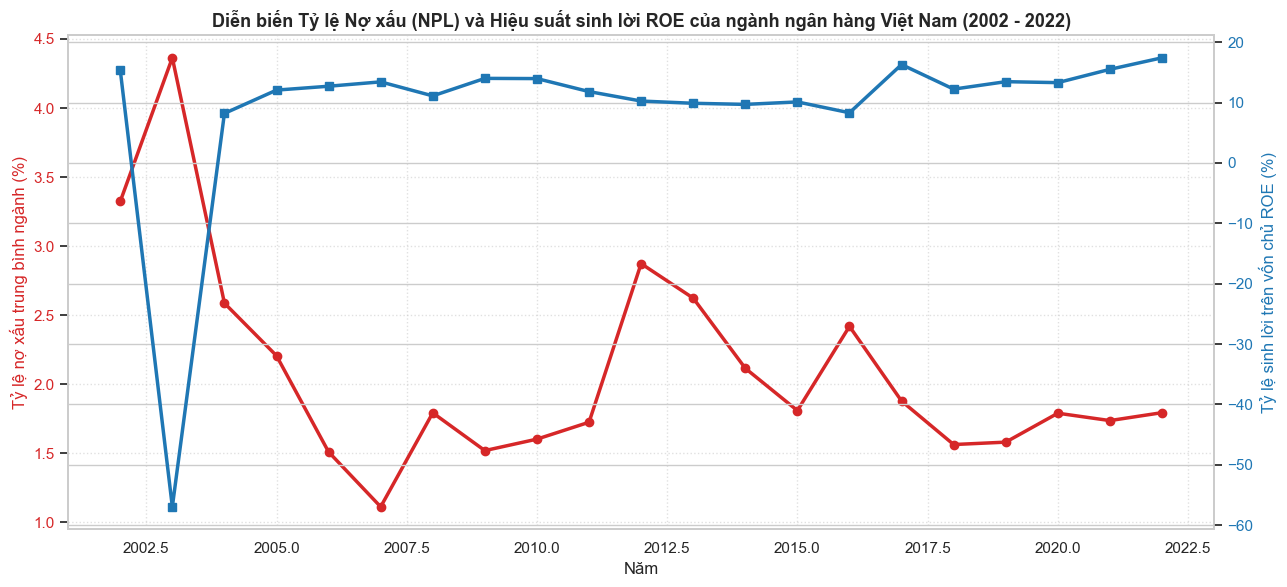

In [4]:
# Tính trung bình ngành theo từng năm
df_yearly_avg = df.groupby("year")[["npl_ratio", "roe", "roa"]].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(13, 6))

color = 'tab:red'
ax1.set_xlabel('Năm', fontsize=12)
ax1.set_ylabel('Tỷ lệ nợ xấu trung bình ngành (%)', color=color, fontsize=12)
ax1.plot(df_yearly_avg['year'], df_yearly_avg['npl_ratio'] * 100, color=color, marker='o', linewidth=2.5, label='NPL Ratio')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle=':', alpha=0.6)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Tỷ lệ sinh lời trên vốn chủ ROE (%)', color=color, fontsize=12)
ax2.plot(df_yearly_avg['year'], df_yearly_avg['roe'] * 100, color=color, marker='s', linewidth=2.5, label='ROE')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Diễn biến Tỷ lệ Nợ xấu (NPL) và Hiệu suất sinh lời ROE của ngành ngân hàng Việt Nam (2002 - 2022)", fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

## 3. Giảm chiều Dữ liệu (PCA)

Đưa dữ liệu CAMELS về không gian các thành phần chính (PCs) để giảm tương quan tuyến tính giữa các biến tài chính.

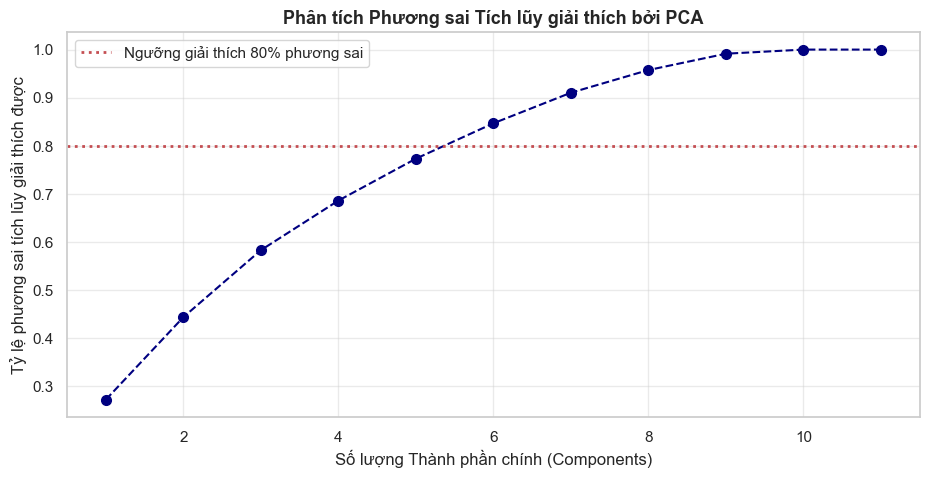

Thành phần chính 1 (PC1) giải thích 27.24% phương sai (Tích lũy: 27.24%)
Thành phần chính 2 (PC2) giải thích 17.14% phương sai (Tích lũy: 44.38%)
Thành phần chính 3 (PC3) giải thích 13.92% phương sai (Tích lũy: 58.30%)
Thành phần chính 4 (PC4) giải thích 10.31% phương sai (Tích lũy: 68.61%)


In [5]:
# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[camels_features])

# Áp dụng PCA
pca = PCA()
pca.fit(X_scaled)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Trực quan hóa tỷ lệ phương sai tích lũy
plt.figure(figsize=(11, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', markersize=7, linestyle='--', color='navy')
plt.axhline(y=0.80, color='r', linestyle=':', linewidth=2, label='Ngưỡng giải thích 80% phương sai')
plt.xlabel('Số lượng Thành phần chính (Components)', fontsize=12)
plt.ylabel('Tỷ lệ phương sai tích lũy giải thích được', fontsize=12)
plt.title('Phân tích Phương sai Tích lũy giải thích bởi PCA', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.show()

# Thống kê 4 thành phần chính đầu tiên
for i, ratio in enumerate(pca.explained_variance_ratio_[:4]):
    print(f"Thành phần chính {i+1} (PC{i+1}) giải thích {ratio*100:.2f}% phương sai (Tích lũy: {cumulative_variance[i]*100:.2f}%)")

## 4. Phân cụm Ngân hàng Toàn ngành (K-Means)

Chiếu dữ liệu lên 4 thành phần chính đầu tiên (giải thích >80% phương sai) và thực hiện phân cụm K-Means để phân chia các ngân hàng thành các nhóm sức khỏe tài chính tương đồng.

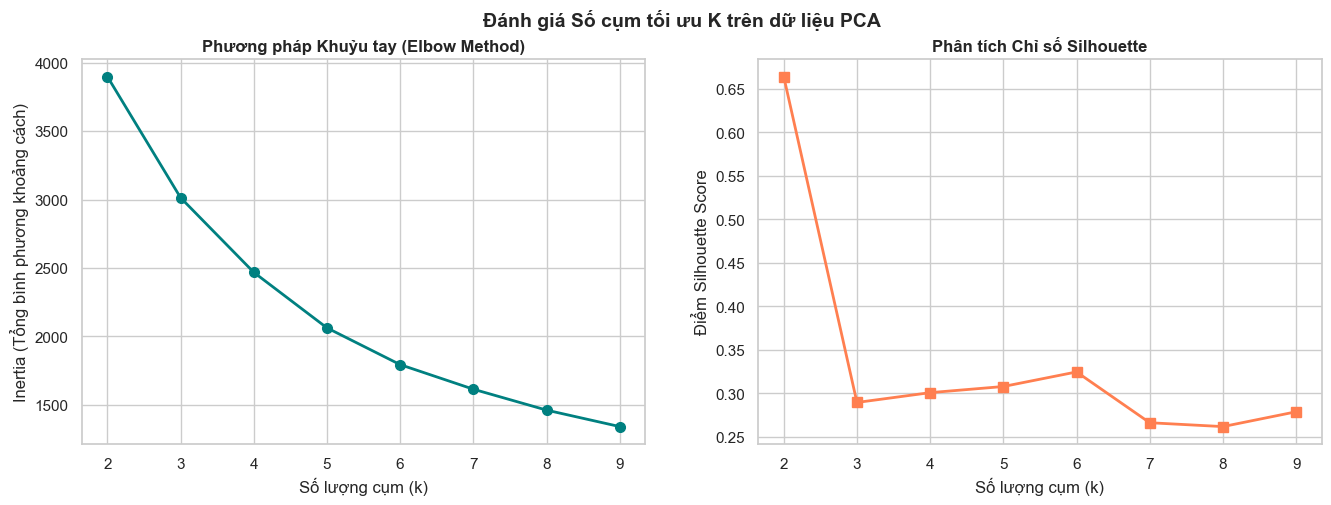

In [6]:
# Chiếu dữ liệu
pca_4 = PCA(n_components=4)
X_pca = pca_4.fit_transform(X_scaled)

# Tính toán Inertia và Silhouette để chọn K tối ưu
inertias = []
silhouette_scores = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, labels))

# Vẽ biểu đồ Elbow và Silhouette
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.plot(k_range, inertias, marker='o', markersize=7, color='teal', linewidth=2)
ax1.set_xlabel('Số lượng cụm (k)', fontsize=12)
ax1.set_ylabel('Inertia (Tổng bình phương khoảng cách)', fontsize=12)
ax1.set_title('Phương pháp Khuỷu tay (Elbow Method)', fontsize=12, fontweight='bold')

ax2.plot(k_range, silhouette_scores, marker='s', markersize=7, color='coral', linewidth=2)
ax2.set_xlabel('Số lượng cụm (k)', fontsize=12)
ax2.set_ylabel('Điểm Silhouette Score', fontsize=12)
ax2.set_title('Phân tích Chỉ số Silhouette', fontsize=12, fontweight='bold')

plt.suptitle('Đánh giá Số cụm tối ưu K trên dữ liệu PCA', fontsize=14, fontweight='bold')
plt.show()

In [7]:
# Huấn luyện K-Means với K=2
kmeans_opt = KMeans(n_clusters=2, random_state=42, n_init=10)
df["cluster"] = kmeans_opt.fit_predict(X_pca)

silhouette = silhouette_score(X_pca, df["cluster"])
db_index = davies_bouldin_score(X_pca, df["cluster"])
print(f"Kết quả với K=2 -> Silhouette: {silhouette:.4f}, Davies-Bouldin Index: {db_index:.4f}")

# Đặc trưng trung bình của từng cụm (Profile)
cluster_profiles = df.groupby("cluster")[camels_features].mean()
print("\nĐặc trưng tài chính trung bình của các Cụm:")
display(cluster_profiles)

Kết quả với K=2 -> Silhouette: 0.6640, Davies-Bouldin Index: 0.9782

Đặc trưng tài chính trung bình của các Cụm:


,npl_ratio,llp_ratio,roa,roe,nim,cir,eta,etd,lta,ltd,gta
cluster,,,,,,,,,,,
0,0.020027,0.013381,0.012422,0.110472,0.071175,0.791803,0.108558,0.239138,0.557788,0.958506,0.557788
1,0.008367,0.007224,0.020480,0.097742,0.501534,0.764469,0.251633,4.408807,0.888548,16.681779,0.888548


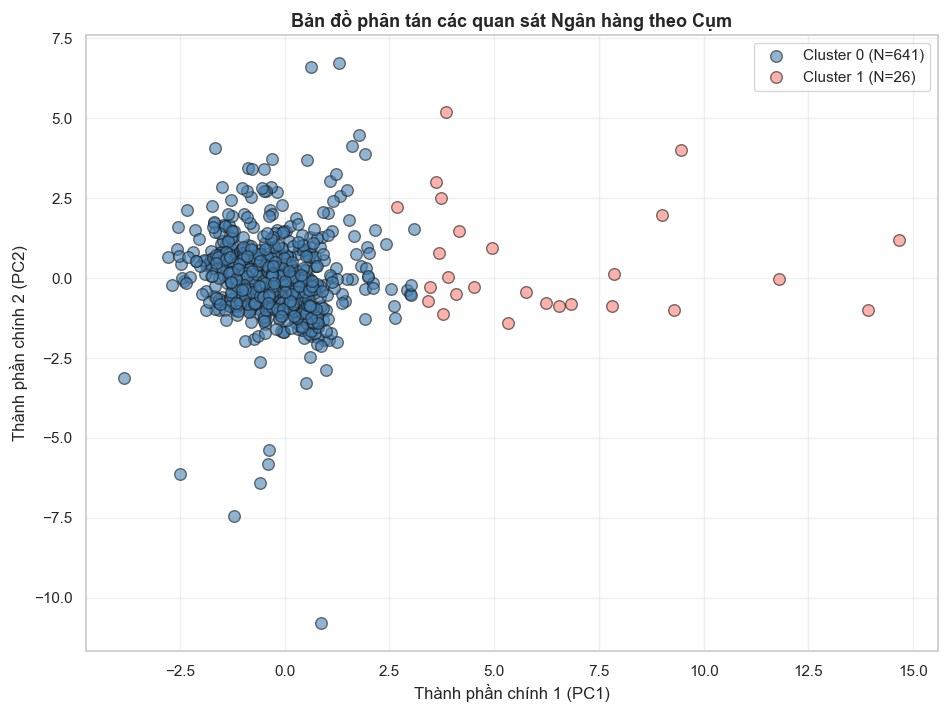

In [8]:
# Trực quan phân tán các cụm trong không gian 2 thành phần chính đầu tiên
plt.figure(figsize=(11, 8))
colors = ['steelblue', 'salmon']
for c in range(2):
    plt.scatter(X_pca[df["cluster"] == c, 0], X_pca[df["cluster"] == c, 1],
                label=f"Cluster {c} (N={len(df[df['cluster'] == c])})",
                c=colors[c], s=70, alpha=0.6, edgecolors='k')

plt.xlabel('Thành phần chính 1 (PC1)', fontsize=12)
plt.ylabel('Thành phần chính 2 (PC2)', fontsize=12)
plt.title('Bản đồ phân tán các quan sát Ngân hàng theo Cụm', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

## 5. Phân loại Rủi ro Tín dụng Nợ xấu (Random Forest)

Xây dựng mô hình Random Forest dự báo sớm nguy cơ nợ xấu tín dụng vượt ngưỡng 3% dựa trên các chỉ số CAMELS và quy mô tài sản/nguồn vốn.

In [9]:
# Gán nhãn mục tiêu
df_rf = df.copy()
df_rf["risk_label"] = (df_rf["npl_ratio"] >= 0.03).astype(int)

scale_features = ["total_assets", "total_deposits", "total_loans", "total_equity"]
rf_features = [c for c in camels_features + scale_features if c != "npl_ratio" and c in df_rf.columns]

# Loại bỏ các dòng khuyết thiếu
df_rf_clean = df_rf.dropna(subset=rf_features + ["risk_label"]).sort_values("date_key").reset_index(drop=True)

# Tách tập dữ liệu theo thời gian (80/20)
split_idx = int(len(df_rf_clean) * 0.8)
X_train = df_rf_clean.iloc[:split_idx][rf_features]
X_test = df_rf_clean.iloc[split_idx:][rf_features]
y_train = df_rf_clean.iloc[:split_idx]["risk_label"]
y_test = df_rf_clean.iloc[split_idx:]["risk_label"]

print(f"Tập huấn luyện (Train): {len(X_train)} quan sát (Số ca rủi ro cao: {y_train.sum()})")
print(f"Tập kiểm thử (Test): {len(X_test)} quan sát (Số ca rủi ro cao: {y_test.sum()})")

# Huấn luyện Random Forest Classifier
rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=5, 
                            class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Dự đoán trên tập kiểm thử
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

# Đánh giá hiệu suất
print("\n=== KẾT QUẢ ĐÁNH GIÁ RANDOM FOREST ===")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"Recall (High Risk class): {recall_score(y_test, y_pred, pos_label=1):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Tập huấn luyện (Train): 528 quan sát (Số ca rủi ro cao: 65)
Tập kiểm thử (Test): 133 quan sát (Số ca rủi ro cao: 14)



=== KẾT QUẢ ĐÁNH GIÁ RANDOM FOREST ===
AUC-ROC: 0.9520
Recall (High Risk class): 0.1429

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.99      0.95       119
           1       0.67      0.14      0.24        14

    accuracy                           0.90       133
   macro avg       0.79      0.57      0.59       133
weighted avg       0.88      0.90      0.87       133



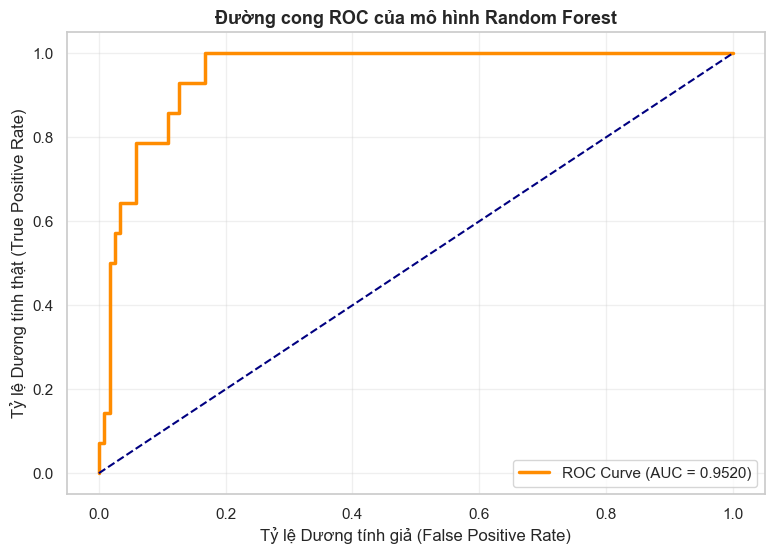

In [10]:
# Vẽ đường cong ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(9, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_prob):.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', linewidth=1.5)
plt.xlabel('Tỷ lệ Dương tính giả (False Positive Rate)', fontsize=12)
plt.ylabel('Tỷ lệ Dương tính thật (True Positive Rate)', fontsize=12)
plt.title('Đường cong ROC của mô hình Random Forest', fontsize=13, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

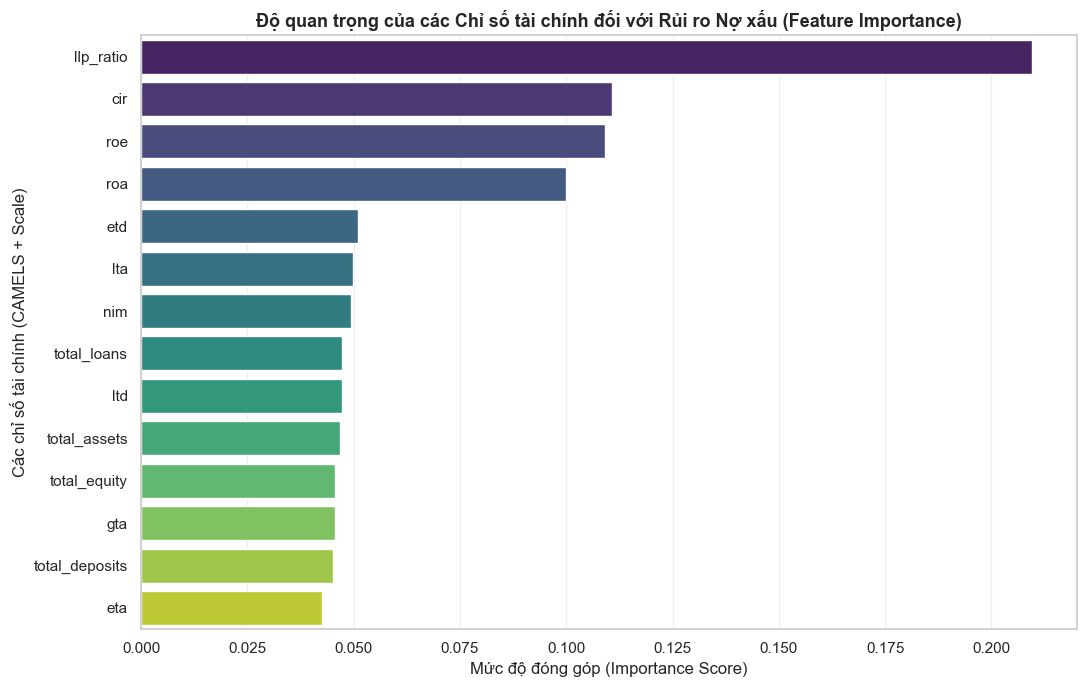

In [11]:
# Trích xuất và biểu diễn mức độ quan trọng của đặc trưng (Feature Importance)
importances = rf.feature_importances_
importance_df = pd.DataFrame({
    "Feature": rf_features,
    "Importance": importances
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(11, 7))
sns.barplot(x="Importance", y="Feature", data=importance_df, hue="Feature", palette="viridis", legend=False)
plt.title("Độ quan trọng của các Chỉ số tài chính đối với Rủi ro Nợ xấu (Feature Importance)", fontsize=13, fontweight='bold')
plt.xlabel("Mức độ đóng góp (Importance Score)", fontsize=12)
plt.ylabel("Các chỉ số tài chính (CAMELS + Scale)", fontsize=12)
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Tổng Hợp Kết Quả Dự Báo Rủi Ro Trên Toàn Ngành

In [12]:
# Gom kết quả dự báo của mô hình cảnh báo sớm trên tập test
test_output = df_rf_clean.iloc[split_idx:].copy()
test_output["predicted_risk"] = y_pred
test_output["risk_probability"] = y_prob

# Trích xuất các ngân hàng bị dán nhãn High Risk (hoặc có xác suất nợ xấu cao nhất)
high_risk_banks = test_output[test_output["predicted_risk"] == 1].sort_values("risk_probability", ascending=False)

print("Danh sách các Ngân hàng bị dự báo thuộc nhóm Rủi ro Nợ xấu cao (NPL >= 3%) trong tập kiểm thử (giai đoạn 2020-2022):")
display(high_risk_banks[["year", "bank_code", "bank_name", "npl_ratio", "predicted_risk", "risk_probability"]].drop_duplicates("bank_code"))

Danh sách các Ngân hàng bị dự báo thuộc nhóm Rủi ro Nợ xấu cao (NPL >= 3%) trong tập kiểm thử (giai đoạn 2020-2022):


,year,bank_code,bank_name,npl_ratio,predicted_risk,risk_probability
562,2019,BVB,Bao Viet Joint Stock Commercial Bank,0.052169,1,0.836239
559,2019,PVB,Vietnam Public Joint Stock Commercial Bank,0.026718,1,0.624672
572,2019,PGB,Petrolimex Group Commercial Joint Stock Bank,0.031592,1,0.580097
